In [1]:
#imported all the required libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

sys.path.insert(0, '/Users/cezar/Documents/Documents_mac/University/TUe/Q6/gym-unbalanced-disk')
import gym_unbalanced_disk

## Environment

The environment is already registered with `max_episode_steps=300` (7.5 s at dt=0.025 s), so we just call `gym.make`. We override `reward_fun` directly — no wrapper class needed.

The default reward is a narrow Gaussian at θ = 180° which gives near-zero signal everywhere else. We use a cosine reward instead:
$$r = \frac{1 - \cos\theta}{2} \quad \in [0, 1]$$
This gives a gradient signal from every position (0 at bottom, 1 at top).

In [2]:
def make_env():
    env = gym.make('unbalanced-disk-sincos-v0')
    # Hardware sysid: real Fc > 8.1 rad/s² (disc stuck at 3.6° with no motor)
    env.unwrapped.Fc = 10.0

    # Velocity penalty near the top — fixes hardware overshoot.
    # r = position_reward * (1 - alpha * omega²)
    # penalty scales with proximity to top so swing-up is unaffected.
    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    return env

env = make_env()
print('obs space :', env.observation_space)
print('action space:', env.action_space)
print('Fc:', env.unwrapped.Fc)

obs space : Box([ -1.  -1. -40.], [ 1.  1. 40.], (3,), float32)
action space: Box(-3.0, 3.0, (), float32)
Fc: 10.0


## PPO Training

Same approach as L8 Exercise 5 but with the unbalanced disc environment. PPO adds a **clipped surrogate objective** on top of A2C to prevent the policy from changing too much in one update:
$$L^{\text{CLIP}} = \mathbb{E}\left[\min\left(r_t A_t,\ \text{clip}(r_t,\ 1{-}\varepsilon,\ 1{+}\varepsilon)\,A_t\right)\right]$$

If the model is already saved, we skip training and load it directly.

In [3]:
import os

MODEL_NAME = 'ppo_swingup_v2'   # v2 = Fc=10, velocity penalty

if os.path.exists(f'{MODEL_NAME}.zip'):
    model = PPO.load(MODEL_NAME)
    print(f'Loaded {MODEL_NAME}.')
else:
    vec_env = make_vec_env(make_env, n_envs=4)
    model = PPO('MlpPolicy', vec_env, learning_rate=3e-4, gamma=0.99,
                ent_coef=0.005, n_steps=1024, batch_size=64, verbose=1, seed=42)
    model.learn(total_timesteps=300_000)
    model.save(MODEL_NAME)
    print(f'Training done, saved {MODEL_NAME}.')

Using cpu device


/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation s

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | 0.554    |
| time/              |          |
|    fps             | 3274     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 300         |
|    ep_rew_mean          | 0.644       |
| time/                   |             |
|    fps                  | 2595        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.006847918 |
|    clip_fraction        | 0.0728      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -4.82       |
|    learning_rate        | 0.

## Evaluation

Total reward: 274.7 / 300


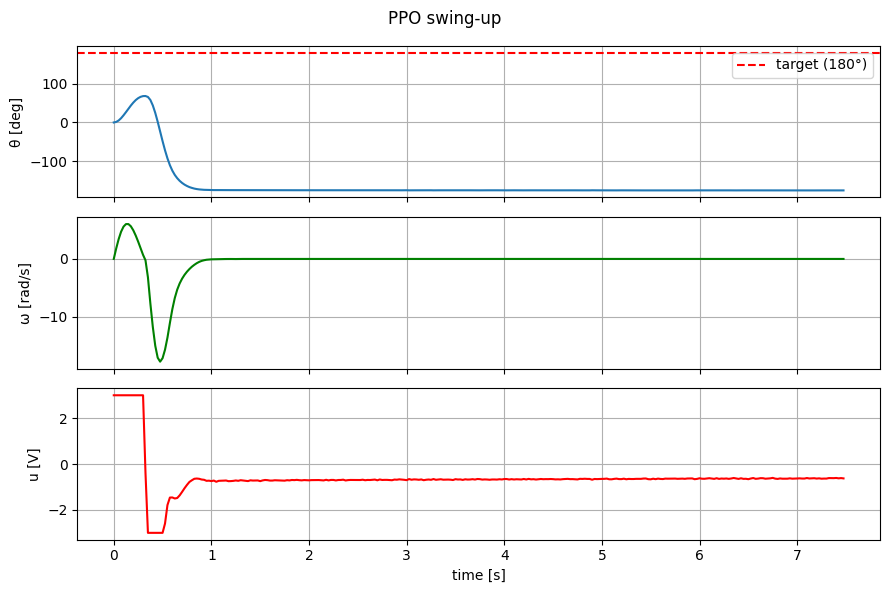

In [4]:
env = make_env()
obs, _ = env.reset()
obs_hist, act_hist, rew_hist = [], [], []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs_hist.append(obs.copy())
    act_hist.append(float(action))
    obs, r, terminated, truncated, _ = env.step(action)
    rew_hist.append(r)
    done = terminated or truncated

obs_arr = np.array(obs_hist)
th_deg  = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
t       = np.arange(len(th_deg)) * 0.025

print(f'Total reward: {sum(rew_hist):.1f} / {len(rew_hist)}')

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, th_deg)
axes[0].axhline(180, color='r', ls='--', label='target (180°)')
axes[0].set_ylabel('θ [deg]');  axes[0].legend();  axes[0].grid(True)
axes[1].plot(t, obs_arr[:, 2], 'g')
axes[1].set_ylabel('ω [rad/s]');  axes[1].grid(True)
axes[2].plot(t, act_hist, 'r')
axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
plt.suptitle('PPO swing-up')
plt.tight_layout()
plt.show()